In [ ]:
import os, re
import matplotlib.pyplot as plt
import numpy as np
import pyxdf
from pathlib import Path
from scipy import signal
from collections import Counter

# ============================================================
# EDIT THIS — path to the .xdf file you want to inspect
# Drop your .xdf files into the EEGData/ folder next to this notebook.
# ============================================================
DATA_DIR = Path("EEGData")
XDF_PATH = DATA_DIR / "Yuta_ses-12hz_task-Default_run-002_eeg.xdf"   # <-- change this filename

# Regex to auto-detect the target frequency from the filename.
# Works for names like: ses-6hz, ses-7.5hz, ses-10hz, etc.
FREQ_REGEX = r"(\d+(?:\.\d+)?)\s*hz"

def parse_expected_freq(path):
    m = re.search(FREQ_REGEX, Path(path).name.lower())
    if not m:
        return None
    return float(m.group(1))

expected_f = parse_expected_freq(XDF_PATH)

# Markers sent by ssvep_stimulus.py:
#   252.0  → experiment started  (SPACE pressed)
#   253.0  → experiment stopped  (SPACE pressed again)
#   100+f  → target cue for frequency f  (e.g. 106.0 = 6 Hz target)
#   f      → per-cycle onset marker at frequency f (e.g. 6.0, 7.5, 10.0 …)
START_MARKERS = ["252.0"]
END_MARKERS   = ["253.0"]

EEG_CHANNEL_IDXS = list(range(8))   # keeps EEG channels 0–7 (drop accel/gyro/battery)

# ============================================================
# Helpers
# ============================================================

def _safe_name(s):
    return s["info"].get("name", ["?"])[0]

def _safe_type(s):
    return s["info"].get("type", ["?"])[0]

def _ch_count(s):
    try:
        return int(s["info"]["channel_count"][0])
    except Exception:
        return 0

def pick_eeg_stream(streams):
    candidates = [
        s for s in streams
        if _ch_count(s) > 1
        and s.get("time_series") is not None
        and s.get("time_stamps") is not None
        and len(s["time_series"]) > 0
        and len(s["time_stamps"]) > 0
    ]
    if not candidates:
        raise ValueError("No EEG-like stream with samples found.")
    return max(candidates, key=lambda s: len(s["time_series"]))

def pick_marker_stream(streams):
    candidates = []
    for s in streams:
        name  = _safe_name(s).lower()
        stype = _safe_type(s).lower()
        ts = s.get("time_series")
        tt = s.get("time_stamps")
        if ts is None or tt is None or len(ts) == 0 or len(tt) == 0:
            continue
        if "marker" in name or "marker" in stype or _ch_count(s) == 1:
            candidates.append(s)
    if not candidates:
        raise ValueError("No marker stream found.")
    return max(candidates, key=lambda s: len(s["time_series"]))

def marker_values_to_strings(marker_stream):
    out = []
    for v in marker_stream["time_series"]:
        if isinstance(v, (list, tuple, np.ndarray)):
            out.append(str(v[0]) if len(v) > 0 else "")
        else:
            out.append(str(v))
    return np.array(out, dtype=object)

def load_xdf_eeg_and_markers(path):
    streams, _ = pyxdf.load_xdf(str(path))

    eeg_stream    = pick_eeg_stream(streams)
    marker_stream = pick_marker_stream(streams)

    X     = np.asarray(eeg_stream["time_series"], dtype=np.float64)
    t_eeg = np.asarray(eeg_stream["time_stamps"],  dtype=np.float64)
    if X.ndim == 1:
        X = X[:, None]
    X = X[:, EEG_CHANNEL_IDXS].T   # (n_ch, n_samples)

    sfreq = 1.0 / np.median(np.diff(t_eeg))

    marker_labels = marker_values_to_strings(marker_stream)
    marker_times  = np.asarray(marker_stream["time_stamps"], dtype=np.float64)

    return X, t_eeg, sfreq, marker_labels, marker_times, eeg_stream, marker_stream

def print_marker_summary(marker_labels):
    c = Counter(marker_labels)
    print("Marker summary:")
    for label, count in c.most_common():
        print(f"  {repr(label)} : {count}")

def build_test_intervals(marker_labels, marker_times, start_markers, end_markers):
    """Pair start/end markers in time order. Returns list of (t_start, t_end)."""
    start_set = set(start_markers)
    end_set   = set(end_markers)
    intervals = []
    active_start = None
    for label, t in zip(marker_labels, marker_times):
        if label in start_set and active_start is None:
            active_start = t
        elif label in end_set and active_start is not None:
            if t > active_start:
                intervals.append((active_start, t))
            active_start = None
    return intervals

def timestamps_to_indices(eeg_timestamps, t_start, t_end):
    i0 = np.searchsorted(eeg_timestamps, t_start, side="left")
    i1 = np.searchsorted(eeg_timestamps, t_end,   side="right")
    return i0, i1

def cut_eeg_to_intervals(X, eeg_timestamps, intervals):
    pieces = []
    for t0, t1 in intervals:
        i0, i1 = timestamps_to_indices(eeg_timestamps, t0, t1)
        if i1 > i0:
            pieces.append(X[:, i0:i1])
    if not pieces:
        raise ValueError("No EEG samples found inside the chosen test intervals.")
    return np.concatenate(pieces, axis=1)

# ============================================================
# RUN
# ============================================================

X, t_eeg, sfreq, marker_labels, marker_times, eeg_stream, marker_stream = load_xdf_eeg_and_markers(XDF_PATH)

print("EEG stream   :", _safe_name(eeg_stream),    "| type:", _safe_type(eeg_stream),    "| shape:", X.shape, "| sfreq:", round(sfreq, 2))
print("Marker stream:", _safe_name(marker_stream), "| type:", _safe_type(marker_stream), "| count:", len(marker_labels))
print()

print_marker_summary(marker_labels)
print()

intervals = build_test_intervals(marker_labels, marker_times, START_MARKERS, END_MARKERS)
print("Detected stimulation intervals (SPACE start → SPACE stop):")
for i, (a, b) in enumerate(intervals, start=1):
    print(f"  {i}. start={a:.3f}  end={b:.3f}  duration={b-a:.3f}s")

X_test_only = cut_eeg_to_intervals(X, t_eeg, intervals)

print()
print("Full recording shape  :", X.shape, f"({X.shape[1]/sfreq:.1f}s)")
print("Stimulation-only shape:", X_test_only.shape, f"({X_test_only.shape[1]/sfreq:.1f}s)")

EEG stream   : Unicorn | type: EEG | shape: (8, 16496) | sfreq: 250.06
Marker stream: SSVEPMarkers | type: Markers | count: 4062

Marker summary:
  '20.0' : 1149
  '15.0' : 864
  '12.0' : 692
  '10.0' : 577
  '7.5' : 432
  '6.0' : 346
  '252.0' : 1
  '253.0' : 1

Detected stimulation intervals (SPACE start → SPACE stop):
  1. start=463710.867  end=463768.599  duration=57.732s

Full recording shape  : (8, 16496) (66.0s)
Stimulation-only shape: (8, 14437) (57.7s)


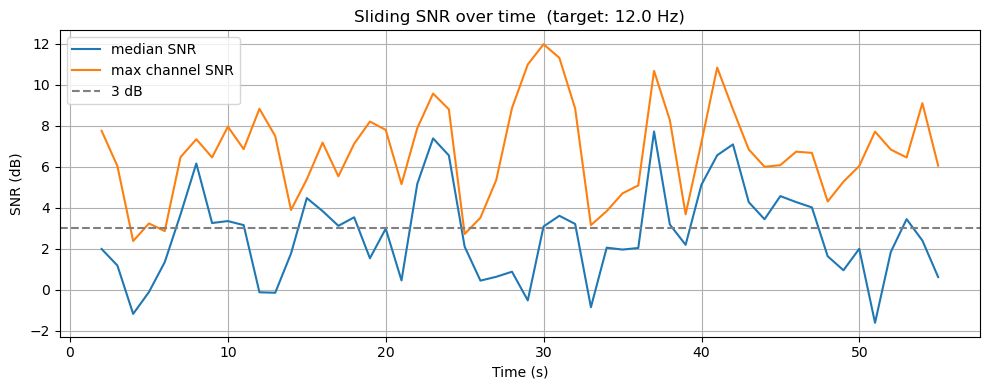

In [46]:
# ============================================================
# Welch PSD + SNR helpers  (used by all later cells)
# ============================================================

def welch_psd(X, sfreq, nperseg_sec=2.0):
    nperseg = int(round(nperseg_sec * sfreq))
    nperseg = max(256, min(nperseg, X.shape[1]))
    f, Pxx = signal.welch(X, fs=sfreq, nperseg=nperseg, axis=-1, detrend="constant")
    return f, Pxx  # Pxx: (n_ch, n_freqs)

def band_snr_db(f, P, f0, bin_half_width=0.15, noise_guard=0.4, noise_width=1.0):
    """
    SNR around f0:
      signal band : [f0-bin_half_width, f0+bin_half_width]
      noise bands : left  [f0-noise_guard-noise_width, f0-noise_guard]
                    right [f0+noise_guard, f0+noise_guard+noise_width]
    Returns SNR in dB for each channel.
    """
    P   = np.asarray(P)
    sig   = (f >= f0 - bin_half_width) & (f <= f0 + bin_half_width)
    left  = (f >= f0 - noise_guard - noise_width) & (f <= f0 - noise_guard)
    right = (f >= f0 + noise_guard) & (f <= f0 + noise_guard + noise_width)
    if sig.sum() == 0 or left.sum() == 0 or right.sum() == 0:
        return None
    sig_pow   = P[:, sig].mean(axis=1)
    noise_pow = 0.5 * (P[:, left].mean(axis=1) + P[:, right].mean(axis=1))
    return 10.0 * np.log10((sig_pow + 1e-20) / (noise_pow + 1e-20))

def sliding_snr_over_time(X, sfreq, expected_f, window_sec=4.0, stride_sec=1.0):
    win    = int(round(window_sec * sfreq))
    stride = int(round(stride_sec * sfreq))
    times, snr_med, snr_max = [], [], []
    for start in range(0, X.shape[1] - win + 1, stride):
        seg = X[:, start:start+win]
        f, Pxx = welch_psd(seg, sfreq, nperseg_sec=window_sec)
        snr = band_snr_db(f, Pxx, expected_f, bin_half_width=0.30, noise_guard=0.5, noise_width=1.5)
        if snr is not None:
            times.append((start + win/2) / sfreq)
            snr_med.append(np.median(snr))
            snr_max.append(np.max(snr))
    return np.array(times), np.array(snr_med), np.array(snr_max)


times, snr_med_t, snr_max_t = sliding_snr_over_time(
    X_test_only, sfreq, expected_f=expected_f, window_sec=4.0, stride_sec=1.0
)

plt.figure(figsize=(10, 4))
plt.plot(times, snr_med_t, label="median SNR")
plt.plot(times, snr_max_t, label="max channel SNR")
plt.axhline(3.0, linestyle="--", color="gray", label="3 dB")
plt.xlabel("Time (s)")
plt.ylabel("SNR (dB)")
plt.title(f"Sliding SNR over time  (target: {expected_f} Hz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Ranking by mean SNR over all windows:
  1. ch06  mean score = 4.98
  2. ch02  mean score = 3.62
  3. ch03  mean score = 3.59
  4. ch00  mean score = 3.58
  5. ch01  mean score = 2.02
  6. ch05  mean score = 0.55
  7. ch04  mean score = -0.42
  8. ch07  mean score = -0.54

Threshold = 5.0 dB

set       #ch   % median>thr   % mean>thr   % max>thr  med(median)
----------------------------------------------------------------------
all         8         14.81%        9.26%      79.63%        2.69
top 8       8         14.81%        9.26%      79.63%        2.69
top 6       6         24.07%       11.11%      79.63%        3.34
top 4       4         37.04%       35.19%      79.63%        3.82


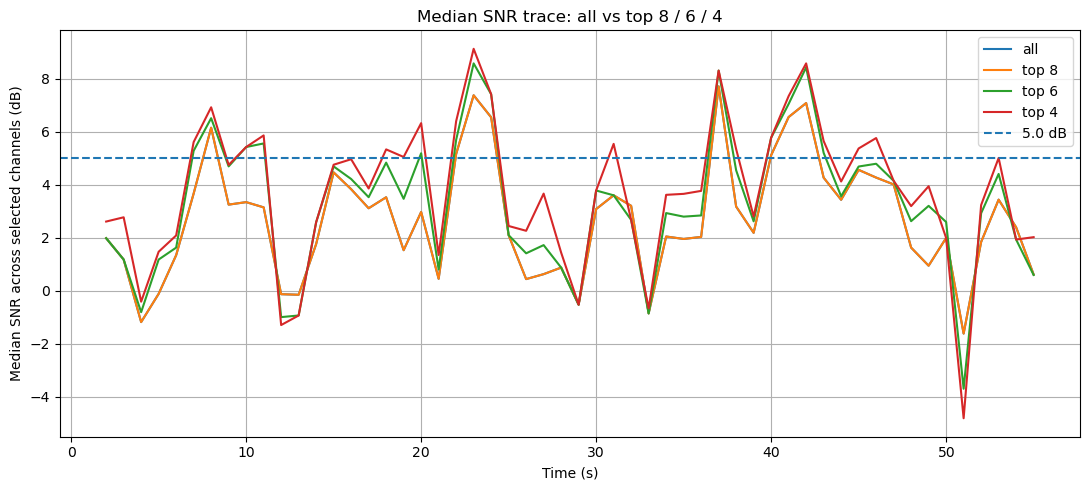


Ranking by good windows only (max channel SNR > 5.0 dB):
Good windows: 43 / 54 (79.63%)
  1. ch06  good-window score = 5.97
  2. ch00  good-window score = 4.14
  3. ch02  good-window score = 4.03
  4. ch03  good-window score = 3.91
  5. ch01  good-window score = 2.03
  6. ch05  good-window score = 0.96
  7. ch04  good-window score = -0.61
  8. ch07  good-window score = -0.62

Threshold = 5.0 dB

set       #ch   % median>thr   % mean>thr   % max>thr  med(median)
----------------------------------------------------------------------
all         8         14.81%        9.26%      79.63%        2.69
top 8       8         14.81%        9.26%      79.63%        2.69
top 6       6         24.07%       11.11%      79.63%        3.34
top 4       4         37.04%       35.19%      79.63%        3.82


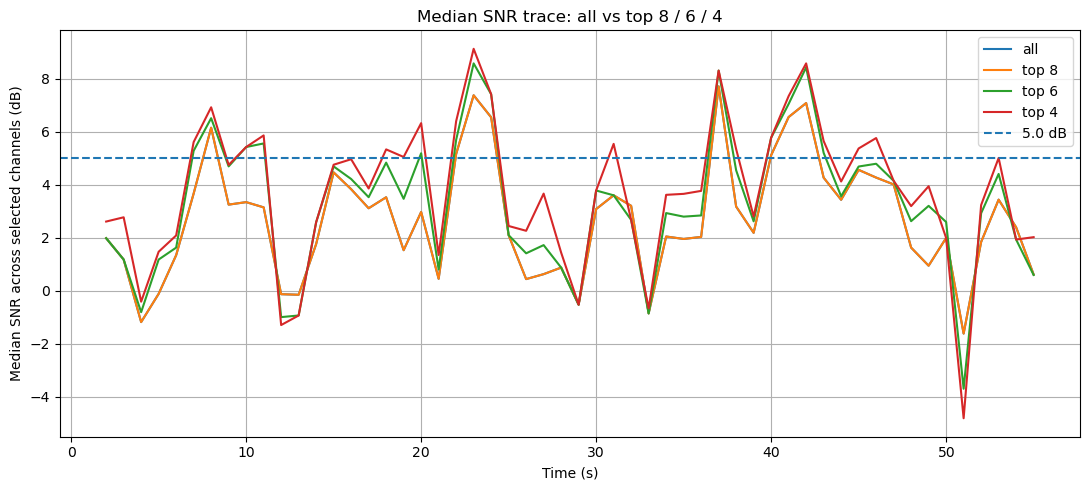

In [47]:
# ============================================================
# Compare channel sets: all vs top 8 vs top 6 vs top 4
# ============================================================

def sliding_snr_matrix_multi(X, sfreq, expected_f, window_sec=4.0, stride_sec=1.0,
                              bin_half_width=0.30, noise_guard=0.5, noise_width=1.5):
    win    = int(round(window_sec * sfreq))
    stride = int(round(stride_sec * sfreq))
    times, rows_f, rows_2f = [], [], []
    for start in range(0, X.shape[1] - win + 1, stride):
        seg = X[:, start:start+win]
        f, Pxx = welch_psd(seg, sfreq, nperseg_sec=window_sec)
        s1 = band_snr_db(f, Pxx, expected_f,          bin_half_width=bin_half_width, noise_guard=noise_guard, noise_width=noise_width)
        s2 = band_snr_db(f, Pxx, 2 * expected_f,      bin_half_width=bin_half_width, noise_guard=noise_guard, noise_width=noise_width)
        if s1 is not None:
            times.append((start + win/2) / sfreq)
            rows_f.append(s1)
            rows_2f.append(s2 if s2 is not None else np.full_like(s1, np.nan))
    if not rows_f:
        raise ValueError("No valid sliding windows produced.")
    return np.array(times), np.vstack(rows_f), np.vstack(rows_2f)


def rank_channels_mean(snr_f):
    score = snr_f.mean(axis=0)
    return np.argsort(score)[::-1], score


def rank_channels_good_windows(snr_f, snr_2f=None, good_window_thresh=5.0):
    combined  = snr_f if snr_2f is None else snr_f + 0.5 * np.nan_to_num(snr_2f, nan=0.0)
    good_mask = np.max(snr_f, axis=1) > good_window_thresh
    if good_mask.sum() == 0:
        raise ValueError(f"No good windows found above {good_window_thresh} dB.")
    score = combined[good_mask].mean(axis=0)
    return np.argsort(score)[::-1], score, good_mask


def summarize_channel_set(name, snr_f, ch_idx, threshold_db=5.0):
    sub          = snr_f[:, ch_idx]
    median_trace = np.median(sub, axis=1)
    mean_trace   = np.mean(sub,   axis=1)
    max_trace    = np.max(sub,    axis=1)
    return {
        "name":                  name,
        "channels":              list(ch_idx),
        "median_trace":          median_trace,
        "mean_trace":            mean_trace,
        "max_trace":             max_trace,
        "pct_median_above":      100 * np.mean(median_trace > threshold_db),
        "pct_mean_above":        100 * np.mean(mean_trace   > threshold_db),
        "pct_max_above":         100 * np.mean(max_trace    > threshold_db),
        "median_of_median_trace": float(np.median(median_trace)),
        "median_of_mean_trace":   float(np.median(mean_trace)),
        "median_of_max_trace":    float(np.median(max_trace)),
    }


def compare_channel_sets(times, snr_f, rank_order, threshold_db=5.0):
    n_ch = snr_f.shape[1]
    sets = {
        "all":    np.arange(n_ch),
        "top 8":  rank_order[:min(8, n_ch)],
        "top 6":  rank_order[:min(6, n_ch)],
        "top 4":  rank_order[:min(4, n_ch)],
    }
    results = [summarize_channel_set(name, snr_f, idx, threshold_db=threshold_db) for name, idx in sets.items()]

    print(f"Threshold = {threshold_db:.1f} dB\n")
    print(f"{'set':<8} {'#ch':>4} {'% median>thr':>14} {'% mean>thr':>12} {'% max>thr':>11} {'med(median)':>12}")
    print("-" * 70)
    for r in results:
        print(f"{r['name']:<8} {len(r['channels']):>4} "
              f"{r['pct_median_above']:>13.2f}% "
              f"{r['pct_mean_above']:>11.2f}% "
              f"{r['pct_max_above']:>10.2f}% "
              f"{r['median_of_median_trace']:>11.2f}")

    plt.figure(figsize=(11, 5))
    for r in results:
        plt.plot(times, r["median_trace"], label=r["name"])
    plt.axhline(threshold_db, linestyle="--", label=f"{threshold_db:.1f} dB")
    plt.xlabel("Time (s)")
    plt.ylabel("Median SNR across selected channels (dB)")
    plt.title("Median SNR trace: all vs top 8 / 6 / 4")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return results


# ── RUN ──────────────────────────────────────────────────────
WINDOW_SEC        = 4.0
STRIDE_SEC        = 1.0
THRESH_DB         = 5.0
GOOD_WINDOW_THRESH = 5.0

times, snr_f_mat, snr_2f_mat = sliding_snr_matrix_multi(
    X_test_only, sfreq, expected_f,
    window_sec=WINDOW_SEC, stride_sec=STRIDE_SEC,
    bin_half_width=0.30, noise_guard=0.5, noise_width=1.5
)

order_mean, score_mean = rank_channels_mean(snr_f_mat)
print("Ranking by mean SNR over all windows:")
for i in range(min(8, len(order_mean))):
    ch = order_mean[i]
    print(f"  {i+1}. ch{ch:02d}  mean score = {score_mean[ch]:.2f}")
print()
results_mean = compare_channel_sets(times, snr_f_mat, order_mean, threshold_db=THRESH_DB)

order_good, score_good, good_mask = rank_channels_good_windows(
    snr_f_mat, snr_2f_mat, good_window_thresh=GOOD_WINDOW_THRESH
)
print(f"\nRanking by good windows only (max channel SNR > {GOOD_WINDOW_THRESH:.1f} dB):")
print(f"Good windows: {good_mask.sum()} / {len(good_mask)} ({100*good_mask.mean():.2f}%)")
for i in range(min(8, len(order_good))):
    ch = order_good[i]
    print(f"  {i+1}. ch{ch:02d}  good-window score = {score_good[ch]:.2f}")
print()
results_good = compare_channel_sets(times, snr_f_mat, order_good, threshold_db=THRESH_DB)

In [48]:
# ============================================================
# Simple SSVEP Frequency Classifier
# Uses Welch PSD + SNR to classify which stimulus frequency
# is most likely present in X_test_only.
#
# Candidate frequencies match ssvep_stimulus.py:
SSVEP_FREQS = [6.0, 7.5, 10.0, 12.0, 15.0, 20.0]
# ============================================================

def _welch_psd(X, sfreq, nperseg_sec=4.0):
    nperseg = int(round(nperseg_sec * sfreq))
    nperseg = max(256, min(nperseg, X.shape[1]))
    f, Pxx = signal.welch(X, fs=sfreq, nperseg=nperseg, axis=-1, detrend="constant")
    return f, Pxx

def _band_snr_db(f, P, f0, bin_half_width=0.30, noise_guard=0.50, noise_width=1.50):
    P     = np.asarray(P)
    sig   = (f >= f0 - bin_half_width) & (f <= f0 + bin_half_width)
    left  = (f >= f0 - noise_guard - noise_width) & (f <= f0 - noise_guard)
    right = (f >= f0 + noise_guard) & (f <= f0 + noise_guard + noise_width)
    if sig.sum() == 0 or left.sum() == 0 or right.sum() == 0:
        return None
    sig_pow   = P[:, sig  ].mean(axis=1)
    noise_pow = 0.5 * (P[:, left].mean(axis=1) + P[:, right].mean(axis=1))
    return 10.0 * np.log10((sig_pow + 1e-20) / (noise_pow + 1e-20))

def _score_frequency(f, Pxx, f0, harmonic_weight=0.5, aggregation="mean"):
    snr_f  = _band_snr_db(f, Pxx, f0)
    snr_2f = _band_snr_db(f, Pxx, 2.0 * f0)
    if snr_f is None:
        return -np.inf
    combined = snr_f if snr_2f is None else snr_f + harmonic_weight * snr_2f
    if   aggregation == "median": return float(np.median(combined))
    elif aggregation == "max":    return float(np.max(combined))
    else:                         return float(np.mean(combined))

def classify_ssvep(X, sfreq, candidate_freqs=None, window_sec=None,
                   harmonic_weight=0.5, aggregation="mean", verbose=True):
    """
    Classify the dominant SSVEP frequency in EEG segment X.

    Parameters
    ----------
    X               : ndarray (n_channels, n_samples)
    sfreq           : float, sampling frequency in Hz
    candidate_freqs : list[float]; defaults to SSVEP_FREQS
    window_sec      : float or None. None = single Welch over full segment;
                      float = sliding windows, scores averaged across windows.
    harmonic_weight : float, weight for the 2nd harmonic SNR term
    aggregation     : "mean" | "median" | "max" over channels
    verbose         : bool, print score table

    Returns
    -------
    best_freq : float
    scores    : dict {freq: score}
    """
    if candidate_freqs is None:
        candidate_freqs = SSVEP_FREQS

    if window_sec is None:
        f, Pxx = _welch_psd(X, sfreq, nperseg_sec=min(4.0, X.shape[1]/sfreq))
        scores = {freq: _score_frequency(f, Pxx, freq, harmonic_weight, aggregation)
                  for freq in candidate_freqs}
    else:
        win    = int(round(window_sec * sfreq))
        stride = max(1, win // 2)
        window_scores = {freq: [] for freq in candidate_freqs}
        for start in range(0, X.shape[1] - win + 1, stride):
            seg = X[:, start:start+win]
            f, Pxx = _welch_psd(seg, sfreq, nperseg_sec=window_sec)
            for freq in candidate_freqs:
                window_scores[freq].append(
                    _score_frequency(f, Pxx, freq, harmonic_weight, aggregation)
                )
        scores = {freq: float(np.mean(ws)) if ws else -np.inf
                  for freq, ws in window_scores.items()}

    best_freq = max(scores, key=scores.get)

    if verbose:
        print("=" * 50)
        print("SSVEP Frequency Classification")
        print("=" * 50)
        print(f"{'Freq (Hz)':<12} {'Score (dB)':<14} {'Predicted?'}")
        print("-" * 40)
        for freq, score in sorted(scores.items(), key=lambda kv: kv[1], reverse=True):
            marker = " ◄ BEST" if freq == best_freq else ""
            print(f"  {freq:<10.2f} {score:<14.4f}{marker}")
        print("=" * 50)
        print(f"Predicted : {best_freq} Hz")
        if expected_f is not None:
            print(f"Expected  : {expected_f} Hz")
            print(f"Correct?  : {'YES ✓' if best_freq == expected_f else 'NO ✗'}")
        print("=" * 50)

    return best_freq, scores


print("\n--- Whole-segment classification ---")
best_freq_A, scores_A = classify_ssvep(
    X_test_only, sfreq,
    candidate_freqs=SSVEP_FREQS,
    window_sec=None,
    harmonic_weight=0.5,
    aggregation="mean",
)

print("\n--- Sliding-window classification (4 s window, 50% overlap) ---")
best_freq_B, scores_B = classify_ssvep(
    X_test_only, sfreq,
    candidate_freqs=SSVEP_FREQS,
    window_sec=4.0,
    harmonic_weight=0.5,
    aggregation="mean",
)


--- Whole-segment classification ---
SSVEP Frequency Classification
Freq (Hz)    Score (dB)     Predicted?
----------------------------------------
  12.00      3.2269         ◄ BEST
  6.00       2.3730        
  10.00      1.6727        
  15.00      -0.3014       
  7.50       -1.4060       
  20.00      -1.4338       
Predicted : 12.0 Hz
Expected  : 12.0 Hz
Correct?  : YES ✓

--- Sliding-window classification (4 s window, 50% overlap) ---
SSVEP Frequency Classification
Freq (Hz)    Score (dB)     Predicted?
----------------------------------------
  12.00      2.0896         ◄ BEST
  10.00      0.7277        
  6.00       0.4706        
  15.00      -1.4194       
  20.00      -2.0175       
  7.50       -2.4460       
Predicted : 12.0 Hz
Expected  : 12.0 Hz
Correct?  : YES ✓


In [24]:
# ============================================================
# Batch SSVEP Classifier Evaluation
#
# Drop all your .xdf files into EEGData/ and fill in the two
# lists below.  The filename is used to auto-detect the true
# frequency via the FREQ_REGEX pattern (e.g. "ses-10hz" → 10.0),
# so you only need to list the filenames — not full paths.
#
# Reuses functions defined in Cell 1 and Cell 4.
# ============================================================

# ── EDIT THESE ───────────────────────────────────────────────
XDF_FILES = [
    DATA_DIR / "your_file_6hz.xdf",
    DATA_DIR / "your_file_7.5hz.xdf",
    DATA_DIR / "your_file_10hz.xdf",
    # add more files here...
]

# Ground-truth frequency (Hz) for each file above (same order).
# If your filenames already contain the frequency (e.g. "ses-6hz")
# you can leave this as None and it will be parsed automatically.
TRUE_FREQS = None   # or e.g. [6.0, 7.5, 10.0]

# ── Classifier settings ───────────────────────────────────────
CANDIDATE_FREQS  = [6.0, 7.5, 10.0, 12.0, 15.0, 20.0]
WINDOW_SEC       = 4.0    # sliding-window length; None = whole-segment
HARMONIC_WEIGHT  = 0.5
AGGREGATION      = "mean"

# ── Auto-parse true freqs from filenames if not provided ──────
if TRUE_FREQS is None:
    TRUE_FREQS = [parse_expected_freq(p) for p in XDF_FILES]
    missing = [str(p) for p, f in zip(XDF_FILES, TRUE_FREQS) if f is None]
    if missing:
        raise ValueError(f"Could not parse frequency from filename(s): {missing}\n"
                         "Set TRUE_FREQS manually or rename the files to include e.g. '10hz'.")

assert len(XDF_FILES) == len(TRUE_FREQS), (
    f"XDF_FILES ({len(XDF_FILES)}) and TRUE_FREQS ({len(TRUE_FREQS)}) must be the same length."
)

# ── SNR helper ────────────────────────────────────────────────
def _compute_true_freq_snr(X, sfreq, true_freq, bin_half_width=0.30,
                            noise_guard=0.50, noise_width=1.50):
    f, Pxx = _welch_psd(X, sfreq, nperseg_sec=min(4.0, X.shape[1]/sfreq))
    snr = _band_snr_db(f, Pxx, true_freq, bin_half_width=bin_half_width,
                        noise_guard=noise_guard, noise_width=noise_width)
    if snr is None:
        return None
    return {
        "snr_per_channel": snr,
        "snr_mean":        float(np.mean(snr)),
        "snr_median":      float(np.median(snr)),
        "snr_max":         float(np.max(snr)),
        "best_channel":    int(np.argmax(snr)),
    }

# ── Batch evaluation ──────────────────────────────────────────
results   = []
n_correct = 0

print(f"Running batch evaluation on {len(XDF_FILES)} file(s)...\n")
print(f"{'#':<4} {'True':>6} {'Pred':>6}  {'OK?':<5}  {'SNR mean':>9}  {'SNR max':>8}  {'Best ch':>7}  File")
print("─" * 100)

for idx, (fpath, true_freq) in enumerate(zip(XDF_FILES, TRUE_FREQS)):
    file_short = Path(fpath).name
    try:
        X, t_eeg, sfreq, marker_labels, marker_times, eeg_s, mkr_s = load_xdf_eeg_and_markers(fpath)
        intervals = build_test_intervals(marker_labels, marker_times, START_MARKERS, END_MARKERS)
        if not intervals:
            raise ValueError("No valid stimulation intervals found in this file.")
        X_trial = cut_eeg_to_intervals(X, t_eeg, intervals)

        pred_freq, scores = classify_ssvep(
            X_trial, sfreq,
            candidate_freqs=CANDIDATE_FREQS,
            window_sec=WINDOW_SEC,
            harmonic_weight=HARMONIC_WEIGHT,
            aggregation=AGGREGATION,
            verbose=False,
        )
        snr_info = _compute_true_freq_snr(X_trial, sfreq, true_freq)

        correct = (pred_freq == true_freq)
        if correct:
            n_correct += 1

        snr_mean_str = f"{snr_info['snr_mean']:>+.2f} dB" if snr_info else "N/A"
        snr_max_str  = f"{snr_info['snr_max']:>+.2f} dB"  if snr_info else "N/A"
        best_ch_str  = f"ch{snr_info['best_channel']:02d}"  if snr_info else "N/A"

        print(f"{idx+1:<4} {true_freq:>6.2f} {pred_freq:>6.2f}  {'✓' if correct else '✗':<5}  "
              f"{snr_mean_str:>9}  {snr_max_str:>8}  {best_ch_str:>7}  {file_short}")
        results.append(dict(file=str(fpath), true_freq=true_freq, pred_freq=pred_freq,
                            correct=correct, scores=scores, snr=snr_info, error=None))

    except Exception as e:
        print(f"{idx+1:<4} {true_freq:>6.2f} {'ERR':>6}  {'?':<5}  "
              f"{'N/A':>9}  {'N/A':>8}  {'N/A':>7}  {file_short}  ← ERROR: {e}")
        results.append(dict(file=str(fpath), true_freq=true_freq, pred_freq=None,
                            correct=False, scores=None, snr=None, error=str(e)))

# ── Summary ───────────────────────────────────────────────────
n_total  = len(XDF_FILES)
n_errors = sum(1 for r in results if r["error"] is not None)
n_scored = n_total - n_errors
accuracy = (n_correct / n_scored * 100) if n_scored > 0 else float("nan")

print("─" * 100)
print(f"Files processed : {n_total}")
print(f"Errors          : {n_errors}")
print(f"Correct         : {n_correct} / {n_scored}")
print(f"Accuracy        : {accuracy:.1f}%")

if n_scored > 0:
    print("\nPer-frequency accuracy:")
    print(f"  {'True freq':>10}  {'Correct':>8}  {'Total':>6}  {'Acc %':>7}")
    print("  " + "─" * 38)
    for freq in CANDIDATE_FREQS:
        freq_results = [r for r in results if r["true_freq"] == freq and r["error"] is None]
        if not freq_results:
            continue
        freq_correct = sum(1 for r in freq_results if r["correct"])
        freq_total   = len(freq_results)
        print(f"  {freq:>10.2f}  {freq_correct:>8}  {freq_total:>6}  {freq_correct/freq_total*100:>6.1f}%")

snr_results = [r for r in results if r["snr"] is not None]
if snr_results:
    print("\nSNR at true frequency (whole-segment Welch PSD):")
    print(f"  {'#':<4} {'True freq':>10}  {'SNR mean':>10}  {'SNR median':>11}  {'SNR max':>9}  {'Best ch':>7}  File")
    print("  " + "─" * 90)
    for idx, r in enumerate(results):
        if r["snr"] is None:
            continue
        s = r["snr"]
        print(f"  {idx+1:<4} {r['true_freq']:>10.2f}  "
              f"{s['snr_mean']:>+9.2f} dB  "
              f"{s['snr_median']:>+10.2f} dB  "
              f"{s['snr_max']:>+8.2f} dB  "
              f"ch{s['best_channel']:02d}     "
              f"{Path(r['file']).name}")

Running batch evaluation on 3 file(s)...

#      True   Pred  OK?     SNR mean   SNR max  Best ch  File
────────────────────────────────────────────────────────────────────────────────────────────────────
1      6.00    ERR  ?            N/A       N/A      N/A  your_file_6hz.xdf  ← ERROR: file EEGData/your_file_6hz.xdf does not exist.
2      7.50    ERR  ?            N/A       N/A      N/A  your_file_7.5hz.xdf  ← ERROR: file EEGData/your_file_7.5hz.xdf does not exist.
3     10.00    ERR  ?            N/A       N/A      N/A  your_file_10hz.xdf  ← ERROR: file EEGData/your_file_10hz.xdf does not exist.
────────────────────────────────────────────────────────────────────────────────────────────────────
Files processed : 3
Errors          : 3
Correct         : 0 / 0
Accuracy        : nan%
